# Czynniki wpływajace na srednia ocene studentow

## Hipotezy badawcze
1. Czy wiek studenta ma wpływ na jego średnią ocenę?
2. Czy czas poświecony na naukę tygodniowo ma wpływ na średnią ocenę?
3. Czy Nieobecności mają wpływ na średnią ocenę?
4. Czy wsparcie rodziców wpływa na średnią ocenę?
5. Czy inne aktywnosci poza szkolne wływaja na srednia ocene?

# import bibliotek


In [173]:
# potrzebne
import math
import pandas as pd
import numpy as np

# preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import PolynomialFeatures
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE

# modele
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# metryki
from sklearn.metrics import classification_report, f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
from sklearn.metrics import accuracy_score

# wizualizacja
import matplotlib.pyplot as plt
import seaborn as sns


# Eksploracja danych

In [174]:
data = pd.read_csv('data/Student_performance_data.csv', index_col='IDStudenta', names=["IDStudenta", "Wiek", "Plec", "Pochodzenie", "WyksztalcenieRodzica", "CzasSpedzonyNaNauceTyg.", "Nieobecnosci", "Tutoring", "WsparcieRodzicow", "ZajeciaPozalekcyjne", "Sport", "Muzyka", "Wolontariat", "SredniaKoncowa"], header=0)


print("Mamy", data.shape[0], "wierszy i", data.shape[1], "kolumn")
data.head()


Mamy 2392 wierszy i 13 kolumn


,Wiek,Plec,Pochodzenie,WyksztalcenieRodzica,CzasSpedzonyNaNauceTyg.,Nieobecnosci,Tutoring,WsparcieRodzicow,ZajeciaPozalekcyjne,Sport,Muzyka,Wolontariat,SredniaKoncowa
IDStudenta,,,,,,,,,,,,,
1001,21,Female,Caucasian,Some College,19.833723,7,Yes,Moderate,0,0,1,0,2.929196
1002,22,Male,Caucasian,High School,15.408756,0,No,Low,0,0,0,0,3.042915
1003,19,Male,Asian,Bachelor's,4.210570,26,No,Moderate,0,0,0,0,0.112602
1004,21,Female,Caucasian,Bachelor's,10.028829,14,No,High,1,0,0,0,2.054218
1005,21,Female,Caucasian,Some College,4.672495,17,Yes,High,0,0,0,0,1.288061


In [175]:
data.describe()

,Wiek,CzasSpedzonyNaNauceTyg.,Nieobecnosci,ZajeciaPozalekcyjne,Sport,Muzyka,Wolontariat,SredniaKoncowa
count,2392.000000,2389.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000
mean,20.468645,9.773029,14.541388,0.383361,0.303512,0.196906,0.157191,1.906186
std,1.123798,5.652477,8.467417,0.486307,0.459870,0.397744,0.364057,0.915156
min,19.000000,0.001057,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,5.043640,7.000000,0.000000,0.000000,0.000000,0.000000,1.174803
50%,20.000000,9.705614,15.000000,0.000000,0.000000,0.000000,0.000000,1.893393
75%,21.000000,14.408321,22.000000,1.000000,1.000000,0.000000,0.000000,2.622216
max,22.000000,19.978094,29.000000,1.000000,1.000000,1.000000,1.000000,4.000000


Wnioski:
- Widzimy ze wartosci sa w formacie tekstowym a powinny byc numeryczne aby modele lepiej dzialaly
- kolumna z 'srednia' nie jest zaokraglona

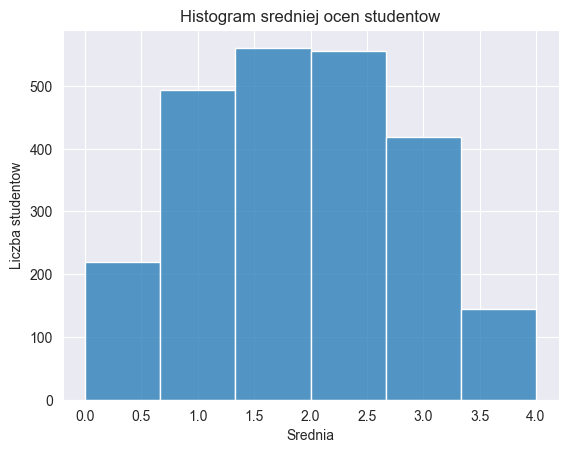

In [176]:
sns.histplot(data['SredniaKoncowa'], bins=6)
plt.xlabel('Srednia')
plt.ylabel('Liczba studentow')
plt.title('Histogram sredniej ocen studentow')
plt.show()

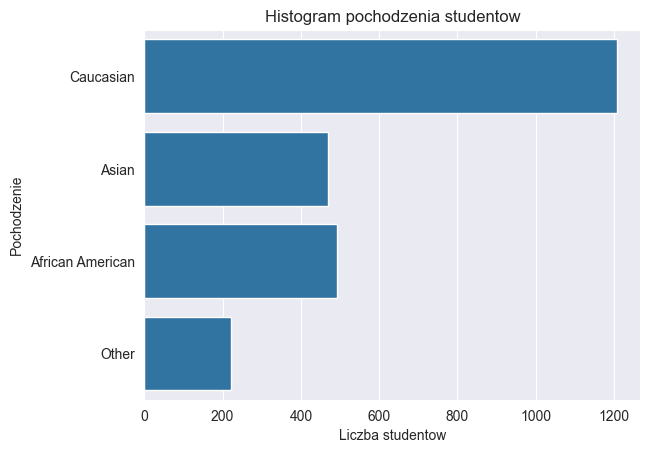

In [177]:
sns.countplot(data['Pochodzenie'])
plt.xlabel('Liczba studentow')
plt.ylabel('Pochodzenie')
plt.title('Histogram pochodzenia studentow')
plt.show()


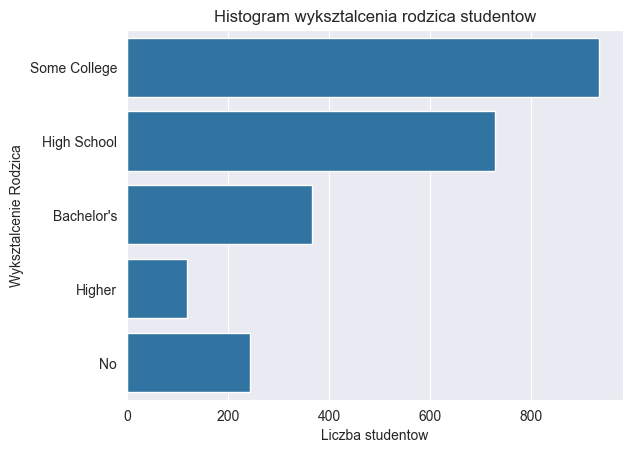

In [178]:
sns.countplot(data['WyksztalcenieRodzica'])
plt.xlabel('Liczba studentow')
plt.ylabel('Wyksztalcenie Rodzica')
plt.title('Histogram wyksztalcenia rodzica studentow')
plt.show()

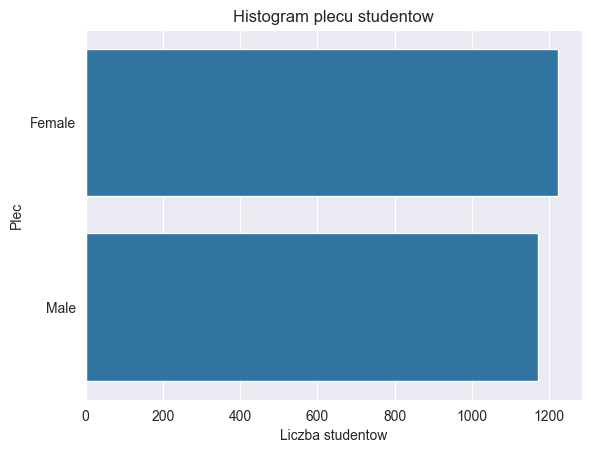

In [179]:
sns.countplot(data['Plec'])
plt.xlabel('Liczba studentow')
plt.ylabel('Plec')
plt.title('Histogram plecu studentow')
plt.show()

# Preprocessing danych

## Uzupelnieie brakujacych wartosci

In [180]:
print(data.isnull().sum()[data.isnull().sum() > 0])
print()
print("Widzimy rownież że mamy brakujacych wartosci ktore nalezy uzupełnić")
print()
data['CzasSpedzonyNaNauceTyg.'] = data['CzasSpedzonyNaNauceTyg.'].fillna(data['CzasSpedzonyNaNauceTyg.'].mean())
print(data.isnull().sum()[data.isnull().sum() > 0])

CzasSpedzonyNaNauceTyg.    3
dtype: int64

Widzimy rownież że mamy brakujacych wartosci ktore nalezy uzupełnić

Series([], dtype: int64)


Uzupelniamy na podstawie wartosci sredniej czasu spedznego na nauce Tygodniowo

## zamiana Wartosci tekstowych na numeryczne

In [181]:
labelEncoder = LabelEncoder()
data['Plec'] = labelEncoder.fit_transform(data['Plec']) # Female -> 0 Male ->1
data['Tutoring'] = labelEncoder.fit_transform(data['Tutoring']) # No -> 0 Yes -> 1

data.head()

,Wiek,Plec,Pochodzenie,WyksztalcenieRodzica,CzasSpedzonyNaNauceTyg.,Nieobecnosci,Tutoring,WsparcieRodzicow,ZajeciaPozalekcyjne,Sport,Muzyka,Wolontariat,SredniaKoncowa
IDStudenta,,,,,,,,,,,,,
1001,21,0,Caucasian,Some College,19.833723,7,1,Moderate,0,0,1,0,2.929196
1002,22,1,Caucasian,High School,15.408756,0,0,Low,0,0,0,0,3.042915
1003,19,1,Asian,Bachelor's,4.210570,26,0,Moderate,0,0,0,0,0.112602
1004,21,0,Caucasian,Bachelor's,10.028829,14,0,High,1,0,0,0,2.054218
1005,21,0,Caucasian,Some College,4.672495,17,1,High,0,0,0,0,1.288061


### 1. Zamiana za pomoca LabelEncoder

In [182]:
# data['Pochodzenie'] = labelEncoder.fit_transform(data['Pochodzenie'])
# data['WyksztalcenieRodzica'] = labelEncoder.fit_transform(data['WyksztalcenieRodzica'])
# data['WsparcieRodzicow'] = labelEncoder.fit_transform(data['WsparcieRodzicow'])
#
# data.head()

In [183]:
# corr = data.corr()
# sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.1f')
# plt.title('Macierz korelacji')
# plt.show()

### 2. Zamiana za pomoca OneHotEncoder

In [184]:
oneHotEncoder = OneHotEncoder(sparse_output=False, drop='first')
oneHotEncoder2 = OneHotEncoder(sparse_output=False, drop='first')
oneHotEncoder3 = OneHotEncoder(sparse_output=False, drop='first')
pochodzenieMatrix = oneHotEncoder.fit_transform(data[['Pochodzenie']])
wyksztalcenieMatrix = oneHotEncoder2.fit_transform(data[['WyksztalcenieRodzica']])
wsparcieRodzicowMatrix = oneHotEncoder3.fit_transform(data[['WsparcieRodzicow']])

pochodzenieDF = pd.DataFrame(pochodzenieMatrix, columns=oneHotEncoder.get_feature_names_out(['Pochodzenie']))
wyksztalcenieDF = pd.DataFrame(wyksztalcenieMatrix, columns=oneHotEncoder2.get_feature_names_out(['WyksztalcenieRodzica']))
wsparcieRodzicowDF = pd.DataFrame(wsparcieRodzicowMatrix, columns=oneHotEncoder3.get_feature_names_out(['WsparcieRodzicow']))

pochodzenieDF.index = data.index
wyksztalcenieDF.index = data.index
wsparcieRodzicowDF.index = data.index

data = pd.concat([data, pochodzenieDF, wyksztalcenieDF, wsparcieRodzicowDF], axis=1)
data.drop(columns=['Pochodzenie', 'WyksztalcenieRodzica', 'WsparcieRodzicow'], inplace=True)

data.head()

,Wiek,Plec,CzasSpedzonyNaNauceTyg.,Nieobecnosci,Tutoring,ZajeciaPozalekcyjne,Sport,Muzyka,Wolontariat,SredniaKoncowa,...,Pochodzenie_Caucasian,Pochodzenie_Other,WyksztalcenieRodzica_High School,WyksztalcenieRodzica_Higher,WyksztalcenieRodzica_No,WyksztalcenieRodzica_Some College,WsparcieRodzicow_Low,WsparcieRodzicow_Moderate,WsparcieRodzicow_Very High,WsparcieRodzicow_Very Low
IDStudenta,,,,,,,,,,,,,,,,,,,,,
1001,21,0,19.833723,7,1,0,0,1,0,2.929196,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1002,22,1,15.408756,0,0,0,0,0,0,3.042915,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1003,19,1,4.210570,26,0,0,0,0,0,0.112602,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1004,21,0,10.028829,14,0,1,0,0,0,2.054218,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1005,21,0,4.672495,17,1,0,0,0,0,1.288061,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


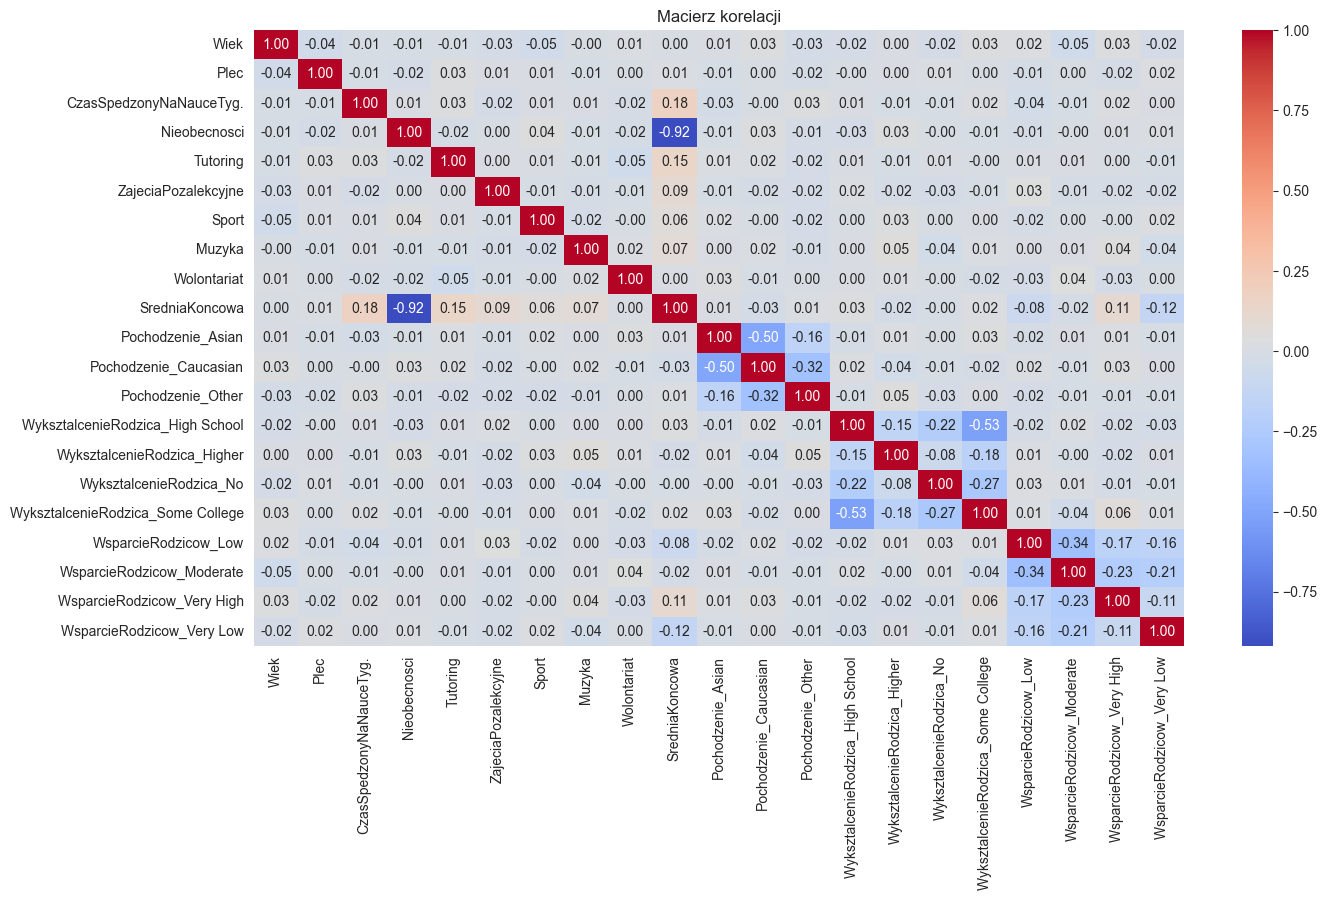

In [185]:
plt.figure(figsize=(15, 8))
corr = data.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Macierz korelacji')
plt.show()

## Wizualizacja

In [186]:
# data['SredniaKoncowa_kategorie'] = pd.cut(data['SredniaKoncowa'], bins=5)
#
# plt.figure(figsize=(15, 8))
# sns.pairplot(data[['Plec','CzasSpedzonyNaNauceTyg.','Nieobecnosci','SredniaKoncowa_kategorie']],
#              diag_kind='kde',
#              hue='SredniaKoncowa_kategorie',
#              kind='reg',
#              plot_kws={'line_kws': {'color': 'red'}})
# plt.title('Wizualizacja danych')
# plt.show()
# data=data.drop(columns=['SredniaKoncowa_kategorie'], axis=1)

# Wybór modeli

## Zmienne ciągłe w kolumnie SredniaKoncowa


### Podzial na zbior testowy i treningowy

In [187]:
X = data.drop(columns=['SredniaKoncowa'], axis=1)
y = data['SredniaKoncowa']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Treningowy zbior:",X_train.shape)
print("Testowy zbior:",X_test.shape)

print()
X_train.head()

Treningowy zbior: (1913, 20)
Testowy zbior: (479, 20)



,Wiek,Plec,CzasSpedzonyNaNauceTyg.,Nieobecnosci,Tutoring,ZajeciaPozalekcyjne,Sport,Muzyka,Wolontariat,Pochodzenie_Asian,Pochodzenie_Caucasian,Pochodzenie_Other,WyksztalcenieRodzica_High School,WyksztalcenieRodzica_Higher,WyksztalcenieRodzica_No,WyksztalcenieRodzica_Some College,WsparcieRodzicow_Low,WsparcieRodzicow_Moderate,WsparcieRodzicow_Very High,WsparcieRodzicow_Very Low
IDStudenta,,,,,,,,,,,,,,,,,,,,
1643,22,0,18.118879,24,1,1,1,0,0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2753,20,0,2.469271,19,0,0,0,0,1,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
2402,21,1,3.456401,25,0,0,0,0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3033,21,0,15.838131,25,1,0,0,0,0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1991,20,1,1.045373,19,1,0,0,1,0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


### Regresja liniowa

In [188]:
regresjaLiniowa = LinearRegression()
regresjaLiniowa.fit(X_train, y_train)

y_pred = regresjaLiniowa.predict(X_test)

r2= r2_score(y_test, y_pred)
print("r2", r2)
print("mean absolute error", mean_absolute_error(y_test, y_pred))

r2 0.953396608823332
mean absolute error 0.15505678108783796


#### Opis

## Klasyfikacja po zkategoryzowaniu srednich

### Dokonujemy Dyskredytacje aby pozniej zrobic klasyfikacje

czyli robimy przedziały z dokładnych srednich ocen

In [189]:
def licz_ocene(srednia):
    if srednia >= 3.5:
        return 4  # A
    elif srednia >= 3.0:
        return 3  # B
    elif srednia >= 2.5:
        return 2  # C
    elif srednia >= 2.0:
        return 1  # D
    else:
        return 0  # F

data['Ocena'] = data['SredniaKoncowa'].apply(licz_ocene)
data[['SredniaKoncowa', 'Ocena']].head(10)


,SredniaKoncowa,Ocena
IDStudenta,,
1001,2.929196,2
1002,3.042915,3
1003,0.112602,0
1004,2.054218,1
1005,1.288061,0
1006,3.084184,3
1007,2.748237,2
1008,1.360143,0
1009,2.896819,2


### Podzial na zbior testowy i treningowy

In [190]:
X = data.drop(columns=['SredniaKoncowa', 'Ocena'])
y = data['Ocena']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Treningowy zbior:",X_train.shape)
print("Testowy zbior:",X_test.shape)

print()
X_train.head()

Treningowy zbior: (1913, 20)
Testowy zbior: (479, 20)



,Wiek,Plec,CzasSpedzonyNaNauceTyg.,Nieobecnosci,Tutoring,ZajeciaPozalekcyjne,Sport,Muzyka,Wolontariat,Pochodzenie_Asian,Pochodzenie_Caucasian,Pochodzenie_Other,WyksztalcenieRodzica_High School,WyksztalcenieRodzica_Higher,WyksztalcenieRodzica_No,WyksztalcenieRodzica_Some College,WsparcieRodzicow_Low,WsparcieRodzicow_Moderate,WsparcieRodzicow_Very High,WsparcieRodzicow_Very Low
IDStudenta,,,,,,,,,,,,,,,,,,,,
1942,19,0,4.843669,21,0,0,0,0,0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
3163,21,1,6.212019,14,0,1,1,1,0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2743,20,1,8.875672,25,0,1,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2408,19,1,4.430543,20,0,1,1,0,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1780,21,1,10.596181,22,0,1,0,0,0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


### standaryzacja

In [191]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Zbior po standaryzacji")
print(np.mean(X_train, axis=0))
print(np.std(X_train, axis=0))

Zbior po standaryzacji
[ 7.60499870e-16  6.49999889e-17  3.08285662e-16  2.50714243e-17
 -4.45714210e-17  6.31428464e-17  7.05714165e-17 -3.62142795e-17
 -6.12857038e-17 -7.42857016e-18 -5.19999911e-17 -2.59999956e-17
  1.85714254e-17  1.07714267e-16 -4.36428497e-17 -9.09999845e-17
 -5.57142762e-18  5.57142762e-18 -5.19999911e-17  2.22857105e-17]
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


### Wyrownywanie wartosci Y

In [192]:
print(y_train.value_counts())

Ocena
0    1019
1     329
2     308
3     195
4      62
Name: count, dtype: int64


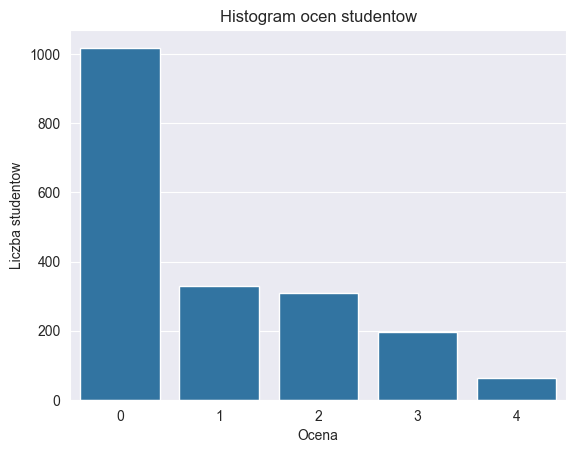

In [193]:
sns.countplot(x=y_train)
plt.xlabel('Ocena')
plt.ylabel('Liczba studentow')
plt.title('Histogram ocen studentow')
plt.show()

Widzimy ze mamy bardzo niezbalansowane dane

#### 1. Udersampling

In [194]:
# underSampler = RandomUnderSampler()
#
# X_train, y_train = underSampler.fit_resample(X_train, y_train)
#
# sns.countplot(x=y_train)
# plt.xlabel('Ocena')
# plt.ylabel('Liczba studentow')
# plt.title('Histogram ocen studentow')
# plt.show()
#
# print("Zbalansowany zbior")
# print(y_train.value_counts())


#### 2. Oversampling

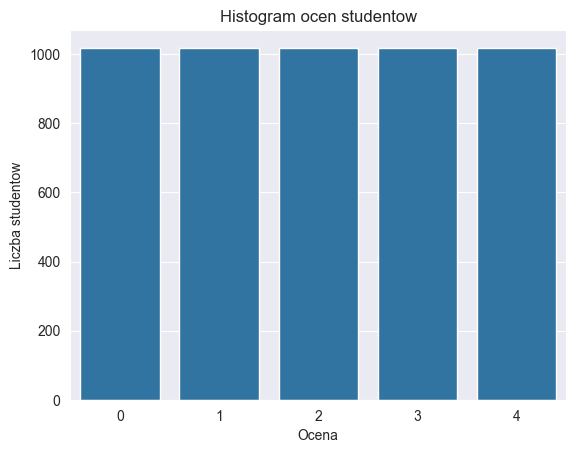

Zbalansowany zbior
Ocena
0    1019
3    1019
2    1019
1    1019
4    1019
Name: count, dtype: int64


In [195]:
oversampler = SMOTE()

X_train, y_train = oversampler.fit_resample(X_train, y_train)

sns.countplot(x=y_train)
plt.xlabel('Ocena')
plt.ylabel('Liczba studentow')
plt.title('Histogram ocen studentow')
plt.show()

print("Zbalansowany zbior")
print(y_train.value_counts())

#### 3. Undersampling + Oversampling

In [196]:
# underSampler = RandomUnderSampler(sampling_strategy='majority',random_state=42)
# oversampler = SMOTE(sampling_strategy='auto', random_state=42)
#
# X_train, y_train = underSampler.fit_resample(X_train, y_train)
# X_train, y_train = oversampler.fit_resample(X_train, y_train)
# sns.countplot(x=y_train)
# plt.xlabel('Ocena')
# plt.ylabel('Liczba studentow')
# plt.title('Histogram ocen studentow')
# plt.show()
# print("Zbalansowany zbior")
# print(y_train.value_counts())


### Regresja Logistyczna

model regresji logistycznej rysuje krzywa S i dzieli ja na 5 przedziałów.

Dokładność: 0.8162839248434238


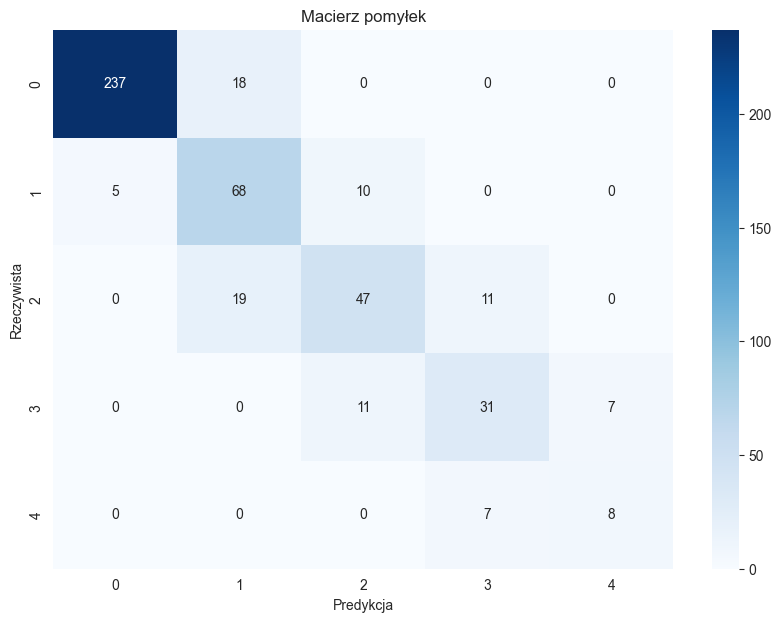

Raport klasyfikacji:
               precision    recall  f1-score   support

           0       0.98      0.93      0.95       255
           1       0.65      0.82      0.72        83
           2       0.69      0.61      0.65        77
           3       0.63      0.63      0.63        49
           4       0.53      0.53      0.53        15

    accuracy                           0.82       479
   macro avg       0.70      0.71      0.70       479
weighted avg       0.83      0.82      0.82       479



In [197]:
LR = LogisticRegression(max_iter=1000)
LR.fit(X_train, y_train)

y_pred = LR.predict(X_test)

accuracyRL= accuracy_score(y_test, y_pred)
print("Dokładność:", accuracyRL)

plt.figure(figsize=(10, 7))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predykcja')
plt.ylabel('Rzeczywista')
plt.title('Macierz pomyłek')
plt.show()

print("Raport klasyfikacji:\n", classification_report(y_test, y_pred))

f1SRL=f1_score(y_test, y_pred, average='macro')

### KNN

KNN tworzy mape punktów i nastepnie szuka najblizszych n punktów do danego punktu

Dokładność: 0.47390396659707723


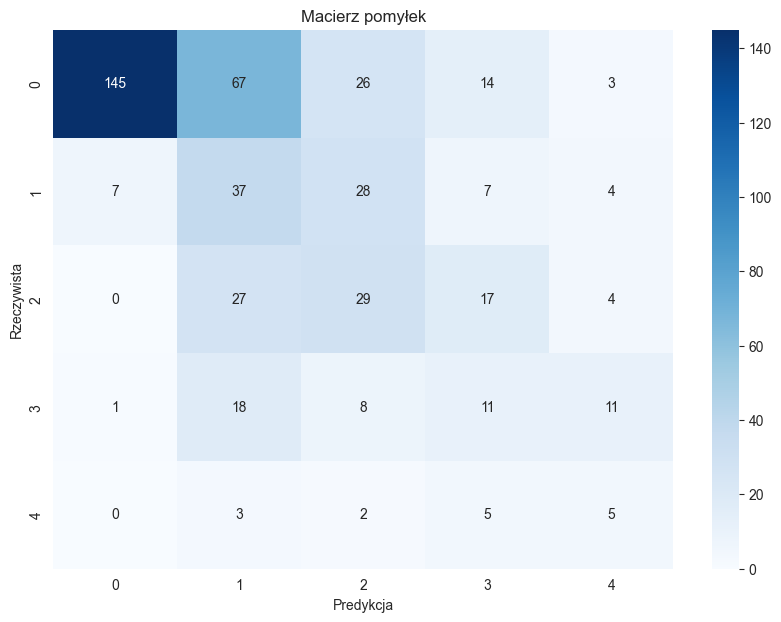

Raport klasyfikacji:
               precision    recall  f1-score   support

           0       0.95      0.57      0.71       255
           1       0.24      0.45      0.31        83
           2       0.31      0.38      0.34        77
           3       0.20      0.22      0.21        49
           4       0.19      0.33      0.24        15

    accuracy                           0.47       479
   macro avg       0.38      0.39      0.36       479
weighted avg       0.62      0.47      0.52       479



In [198]:
knn = KNeighborsClassifier(n_neighbors=10)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

accuracyKNN = accuracy_score(y_test, y_pred)
print("Dokładność:", accuracyKNN)
plt.figure(figsize=(10, 7))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predykcja')
plt.ylabel('Rzeczywista')
plt.title('Macierz pomyłek')
plt.show()
print("Raport klasyfikacji:\n", classification_report(y_test, y_pred))

f1SKNN=f1_score(y_test, y_pred, average='macro')

### SVM

SVM tworzy kreske dzielaca punkty na grupy w taki sposob aby była jak najdalej od punktów, kategoryzujac je

Dokładność: 0.8162839248434238


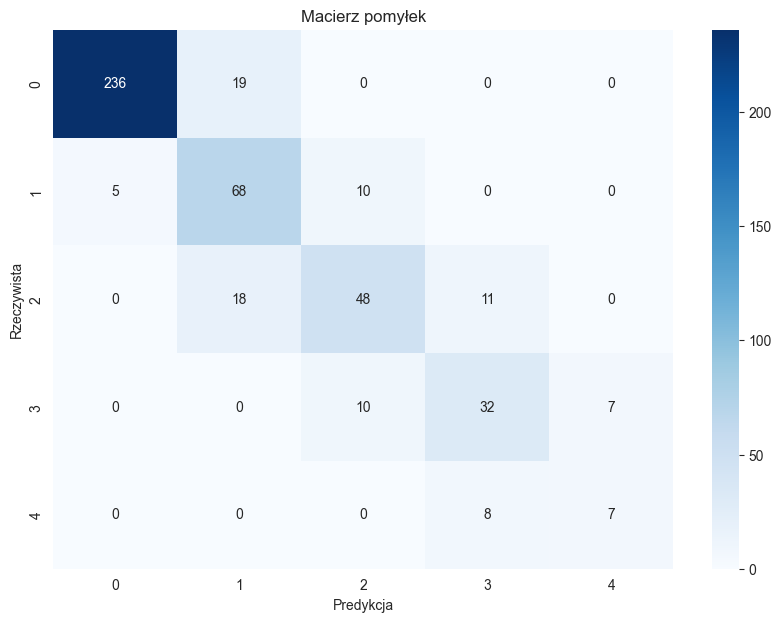

Raport klasyfikacji:
               precision    recall  f1-score   support

           0       0.98      0.93      0.95       255
           1       0.65      0.82      0.72        83
           2       0.71      0.62      0.66        77
           3       0.63      0.65      0.64        49
           4       0.50      0.47      0.48        15

    accuracy                           0.82       479
   macro avg       0.69      0.70      0.69       479
weighted avg       0.83      0.82      0.82       479



In [199]:
svm = SVC(kernel='linear')
svm.fit(X_train, y_train)

y_pred = svm.predict(X_test)

accuracySVM = accuracy_score(y_test, y_pred)
print("Dokładność:", accuracySVM)
plt.figure(figsize=(10, 7))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predykcja')
plt.ylabel('Rzeczywista')
plt.title('Macierz pomyłek')
plt.show()
print("Raport klasyfikacji:\n", classification_report(y_test, y_pred))

f1SVM=f1_score(y_test, y_pred, average='macro')

# Podsumowanie wyników

In [200]:
# wybor najlepszego modelu

print("Dokładnosc regresji liniowej:", round(r2,2))
print("f1 regresji logistycznej:", round(f1SRL,2), "accuracy:", round(accuracyRL,2))
print("f1 KNN:", round(f1SKNN,2), "accuracy:", round(accuracyKNN,2))
print("f1 SVM:", round(f1SVM,2), "accuracy:", round(accuracySVM,2))


Dokładnosc regresji liniowej: 0.95
f1 regresji logistycznej: 0.7 accuracy: 0.82
f1 KNN: 0.36 accuracy: 0.47
f1 SVM: 0.69 accuracy: 0.82


## Wnioski (Poprawic wnioski )
1. Na podstawie tych danych oraz tablicy korelacji możemu zauważyc ze Ważnym czynnikiem sa:
- nieobecnosci
- czas spedzony na nauce tygodniowo
- Tutoring
- wsparcie rodziców
Na wyniki nie wpływa:
- wiek
- plec
- pochodzenie
- wykształcenie rodziców
Oraz w mniejszym stopniu
- zajęcia pozalekcyjne
- sport
- muzyka
- wolontariat

2. Widzimy ze mamy bardzo niezbalansowane dane co nie dawało najlepsych wynikow. Najlepszym rozwiazaniem okazał się oversampling

3. Najlepszym modelem dla wartosci ciągłej jest regresja liniowa z wynikiem r2=0.95 a dla wartosci zkategoryzowanych regresja logistyczna z wynikiem f1=0.7




# CO trzeba zrobic ?
- Stworzyc podpisy włumaczace wszytsko
- pomyslec czy nei mozna zrobic lepszej wizualizacji danych
- "3.Zastosowanie wybranego algorytmu do redukcji wymiarowości:Wizualizacja danych w przestrzeni 2D/3D + interpretacja."
- uzasadnic wyhor modelu ?
- zrobic lepsze porownanie